## **Hypotheses**
H1: Weather Impact Hypothesis

H₀: Weather delay ka arrival delay par koi significant effect nahi hai.

H₁: Weather delay badhne par arrival delay significantly increase hota hai.

H2: Late Aircraft Effect Hypothesis

H₀: Late aircraft delay aur arrival delay ke beech koi relationship nahi hai.

H₁: Late aircraft delay arrival delay ka strongest predictor hai.

H3: Airline Performance Hypothesis

H₀: Different airlines (Top_Carriers) ke average delays me koi significant difference nahi hai.

H₁: Different airlines ke average delays me significant difference hai.

### **Business Problem Statement**

- What are the main causes of flight delays?
- Which airports have the highest delays?
- Which airlines perform best and worst?
- Does departure delay affect arrival delay?
- Does weather increase delays and cancellations?
- Do flight timings affect delays?
- How can airlines reduce delays and cancellations?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\nehak\Downloads\airline_flight.csv")
df

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
0,5,BOS,600,554,-6,711,707,-4,0,0,0,187,0,0,0,0,0,1
1,6,BOS,600,554,-6,711,703,-8,0,0,0,187,0,0,0,0,0,1
2,1,BOS,600,601,1,711,706,-5,0,0,0,187,0,0,0,0,0,1
3,2,BOS,600,556,-4,711,709,-2,0,0,0,187,0,0,0,0,0,1
4,3,BOS,600,552,-8,711,659,-12,0,0,0,187,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4816,4,LAX,815,845,30,1652,1728,36,1,0,0,2611,30,0,6,0,0,1
4817,5,LAX,815,811,-4,1652,1626,-26,0,0,0,2611,0,0,0,0,0,1
4818,7,LAX,815,809,-6,1652,1619,-33,0,0,0,2611,0,0,0,0,0,1
4819,1,LAX,815,811,-4,1652,1709,17,1,0,0,2611,0,0,17,0,0,1


In [3]:
df.head()

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
0,5,BOS,600,554,-6,711,707,-4,0,0,0,187,0,0,0,0,0,1
1,6,BOS,600,554,-6,711,703,-8,0,0,0,187,0,0,0,0,0,1
2,1,BOS,600,601,1,711,706,-5,0,0,0,187,0,0,0,0,0,1
3,2,BOS,600,556,-4,711,709,-2,0,0,0,187,0,0,0,0,0,1
4,3,BOS,600,552,-8,711,659,-12,0,0,0,187,0,0,0,0,0,1


In [4]:
df.columns

Index(['DayOfWeek', 'Origin_Airport', 'Scheduled_Departure', 'Departure_Time',
       'Dep_Delay', 'Scheduled_Arrival', 'Arrival_Time', 'Arrival_Delay',
       'Arr_Del_morethan15', 'Cancelled', 'Diverted', 'Distance',
       'Carrier_Delay', 'WeatherDelay', 'NAS_Delay', 'Security_Delay',
       'Late_Aircraft_Delay', 'Top_Carriers'],
      dtype='object')

##### Dataset Features
- DayOfWeek – Flight week ke kis din operate hui (Monday, Tuesday, etc.).


- Origin_Airport – Airport jahan se flight ne departure kiya.
- Scheduled_Departure – Flight ka planned departure time.
- Departure_Time – Flight ka actual departure time.
Dep_Delay – Departure me kitne minutes ki delay hui.
- Scheduled_Arrival – Flight ka planned arrival time.
- Arrival_Time – Flight ka actual arrival time.
- Arrival_Delay – Arrival me kitne minutes ki delay hui.
- Arr_Del_morethan15 – Arrival delay 15 minutes se zyada thi ya nahi.
- Cancelled – Flight cancel hui ya nahi.
- Diverted – Flight ko kisi dusre airport par divert kiya gaya ya nahi.
- Distance – Flight dwara travel ki gayi total distance.
Carrier_Delay – Airline ki operational problems (crew, maintenance, scheduling) ki wajah se hua delay.
- WeatherDelay – Kharab weather conditions ki wajah se hua delay.
- NAS_Delay – Air traffic control ya airport congestion ki wajah se hua delay.
- Security_Delay – Security-related issues ki wajah se hua delay.
- Late_Aircraft_Delay – Previous flight late aane ki wajah se hua delay.
- Top_Carriers – Flight operate karne wali airline/carrier.

In [5]:
df.info()   				

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4821 entries, 0 to 4820
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   DayOfWeek            4821 non-null   int64 
 1   Origin_Airport       4821 non-null   object
 2   Scheduled_Departure  4821 non-null   int64 
 3   Departure_Time       4821 non-null   int64 
 4   Dep_Delay            4821 non-null   int64 
 5   Scheduled_Arrival    4821 non-null   int64 
 6   Arrival_Time         4821 non-null   int64 
 7   Arrival_Delay        4821 non-null   int64 
 8   Arr_Del_morethan15   4821 non-null   int64 
 9   Cancelled            4821 non-null   int64 
 10  Diverted             4821 non-null   int64 
 11  Distance             4821 non-null   int64 
 12  Carrier_Delay        4821 non-null   int64 
 13  WeatherDelay         4821 non-null   int64 
 14  NAS_Delay            4821 non-null   int64 
 15  Security_Delay       4821 non-null   int64 
 16  Late_A

####  **Data Cleaning and Preprocesing**
##### Time Feature Processing
- Converted Departure_Time and Scheduled_Departure columns into proper time format for analysis.
- Identified 2 invalid records in the Departure_Time column during the conversion process.
- Removed the invalid records to ensure data quality and consistency.
- Created a new feature called Departure_Period based on departure time.
- Categorized departures into Night, Morning, Afternoon, and Evening periods.
- This new feature enables better analysis of flight patterns and delays across different times of the day.

In [6]:
df.duplicated().sum()

np.int64(8)

In [7]:
df.drop_duplicates()

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
0,5,BOS,600,554,-6,711,707,-4,0,0,0,187,0,0,0,0,0,1
1,6,BOS,600,554,-6,711,703,-8,0,0,0,187,0,0,0,0,0,1
2,1,BOS,600,601,1,711,706,-5,0,0,0,187,0,0,0,0,0,1
3,2,BOS,600,556,-4,711,709,-2,0,0,0,187,0,0,0,0,0,1
4,3,BOS,600,552,-8,711,659,-12,0,0,0,187,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4816,4,LAX,815,845,30,1652,1728,36,1,0,0,2611,30,0,6,0,0,1
4817,5,LAX,815,811,-4,1652,1626,-26,0,0,0,2611,0,0,0,0,0,1
4818,7,LAX,815,809,-6,1652,1619,-33,0,0,0,2611,0,0,0,0,0,1
4819,1,LAX,815,811,-4,1652,1709,17,1,0,0,2611,0,0,17,0,0,1


In [8]:
df.isnull().sum()

DayOfWeek              0
Origin_Airport         0
Scheduled_Departure    0
Departure_Time         0
Dep_Delay              0
Scheduled_Arrival      0
Arrival_Time           0
Arrival_Delay          0
Arr_Del_morethan15     0
Cancelled              0
Diverted               0
Distance               0
Carrier_Delay          0
WeatherDelay           0
NAS_Delay              0
Security_Delay         0
Late_Aircraft_Delay    0
Top_Carriers           0
dtype: int64

- This dataset before 4821  records after removing dataset 4813  records after remove duplicates.
- And no misisng records.

#### Change data type for better eda

In [9]:
df['Departure_Time'].astype(str).str.len().value_counts()

Departure_Time
4    3299
3    1471
2      34
1      17
Name: count, dtype: int64

In [10]:
df['Departure_Time'] = pd.to_datetime(
    df['Departure_Time'].astype(str).str.zfill(4),
    format='%H%M',
    errors='coerce'
).dt.time

df['Scheduled_Departure'] = pd.to_datetime(
    df['Scheduled_Departure'].astype(str).str.zfill(4),
    format='%H%M',
    errors='coerce'
).dt.time




In [11]:
df['Departure_Time'].isna().sum()

np.int64(2)

In [12]:
df = df.dropna(subset=['Departure_Time'])

In [13]:
df['Scheduled_Departure'].isna().sum()

np.int64(0)

In [14]:
print(df["Scheduled_Departure"].dtype)
print(type(df["Scheduled_Departure"].iloc[0]))
print(df["Scheduled_Departure"].head())

object
<class 'datetime.time'>
0    06:00:00
1    06:00:00
2    06:00:00
3    06:00:00
4    06:00:00
Name: Scheduled_Departure, dtype: object


In [15]:
df.loc[:, "Departure_Period"] = df["Scheduled_Departure"].apply(
    lambda x: "Night" if x.hour < 6
    else "Morning" if x.hour < 12
    else "Afternoon" if x.hour < 18
    else "Evening"
)

C:\Users\nehak\AppData\Local\Temp\ipykernel_12192\664082292.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "Departure_Period"] = df["Scheduled_Departure"].apply(


In [16]:
df.head()

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers,Departure_Period
0,5,BOS,06:00:00,05:54:00,-6,711,707,-4,0,0,0,187,0,0,0,0,0,1,Morning
1,6,BOS,06:00:00,05:54:00,-6,711,703,-8,0,0,0,187,0,0,0,0,0,1,Morning
2,1,BOS,06:00:00,06:01:00,1,711,706,-5,0,0,0,187,0,0,0,0,0,1,Morning
3,2,BOS,06:00:00,05:56:00,-4,711,709,-2,0,0,0,187,0,0,0,0,0,1,Morning
4,3,BOS,06:00:00,05:52:00,-8,711,659,-12,0,0,0,187,0,0,0,0,0,1,Morning


In [17]:
df['Origin_Airport'].nunique()

18

In [18]:
df['DayOfWeek'].value_counts()

DayOfWeek
7    789
5    779
6    701
3    644
2    641
4    639
1    626
Name: count, dtype: int64

In [19]:

df['Scheduled_Departure'].value_counts()

Scheduled_Departure
06:00:00    174
08:15:00    170
17:00:00    152
15:30:00    146
08:00:00    117
           ... 
11:54:00      1
06:59:00      1
16:35:00      1
06:29:00      1
00:40:00      1
Name: count, Length: 159, dtype: int64

In [20]:
df['Dep_Delay'].value_counts()

Dep_Delay
-3      354
-4      344
-2      339
-5      302
-6      282
       ... 
 185      1
 328      1
 238      1
 170      1
 294      1
Name: count, Length: 270, dtype: int64

In [21]:
df['Departure_Period'].value_counts()

Departure_Period
Morning      1984
Afternoon    1641
Evening      1093
Night         101
Name: count, dtype: int64

In [22]:
df.describe()

,DayOfWeek,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
count,4819.000000,4819.000000,4819.000000,4819.000000,4819.000000,4819.000000,4819.0,4819.0,4819.000000,4819.000000,4819.000000,4819.000000,4819.000000,4819.000000,4819.0
mean,4.154389,22.066819,1502.442000,1468.752646,19.442000,0.322059,0.0,0.0,1549.211662,7.491181,1.383067,6.818842,0.051463,8.965968,1.0
std,2.007207,68.817626,562.107045,600.186967,71.907161,0.467314,0.0,0.0,914.907348,42.413642,19.503961,24.964819,1.525162,39.963242,0.0
min,1.000000,-20.000000,5.000000,1.000000,-58.000000,0.000000,0.0,0.0,187.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,2.000000,-4.000000,1131.000000,1054.000000,-11.000000,0.000000,0.0,0.0,740.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,4.000000,0.000000,1549.000000,1538.000000,0.000000,0.000000,0.0,0.0,1438.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
75%,6.000000,20.000000,1937.000000,1943.000000,25.000000,1.000000,0.0,0.0,2475.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
max,7.000000,1333.000000,2359.000000,2400.000000,1355.000000,1.000000,0.0,0.0,3784.000000,1189.000000,1010.000000,359.000000,68.000000,1333.000000,1.0


- mostly flight operate 4 day of week me ho rhi he 


#### **Univariate Analysis**

In [23]:
# Numerical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)


Numerical Columns:
['DayOfWeek', 'Dep_Delay', 'Scheduled_Arrival', 'Arrival_Time', 'Arrival_Delay', 'Arr_Del_morethan15', 'Cancelled', 'Diverted', 'Distance', 'Carrier_Delay', 'WeatherDelay', 'NAS_Delay', 'Security_Delay', 'Late_Aircraft_Delay', 'Top_Carriers']


In [24]:
# Categorical Columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nCategorical Columns:")
print(categorical_cols)


Categorical Columns:
['Origin_Airport', 'Scheduled_Departure', 'Departure_Time', 'Departure_Period']


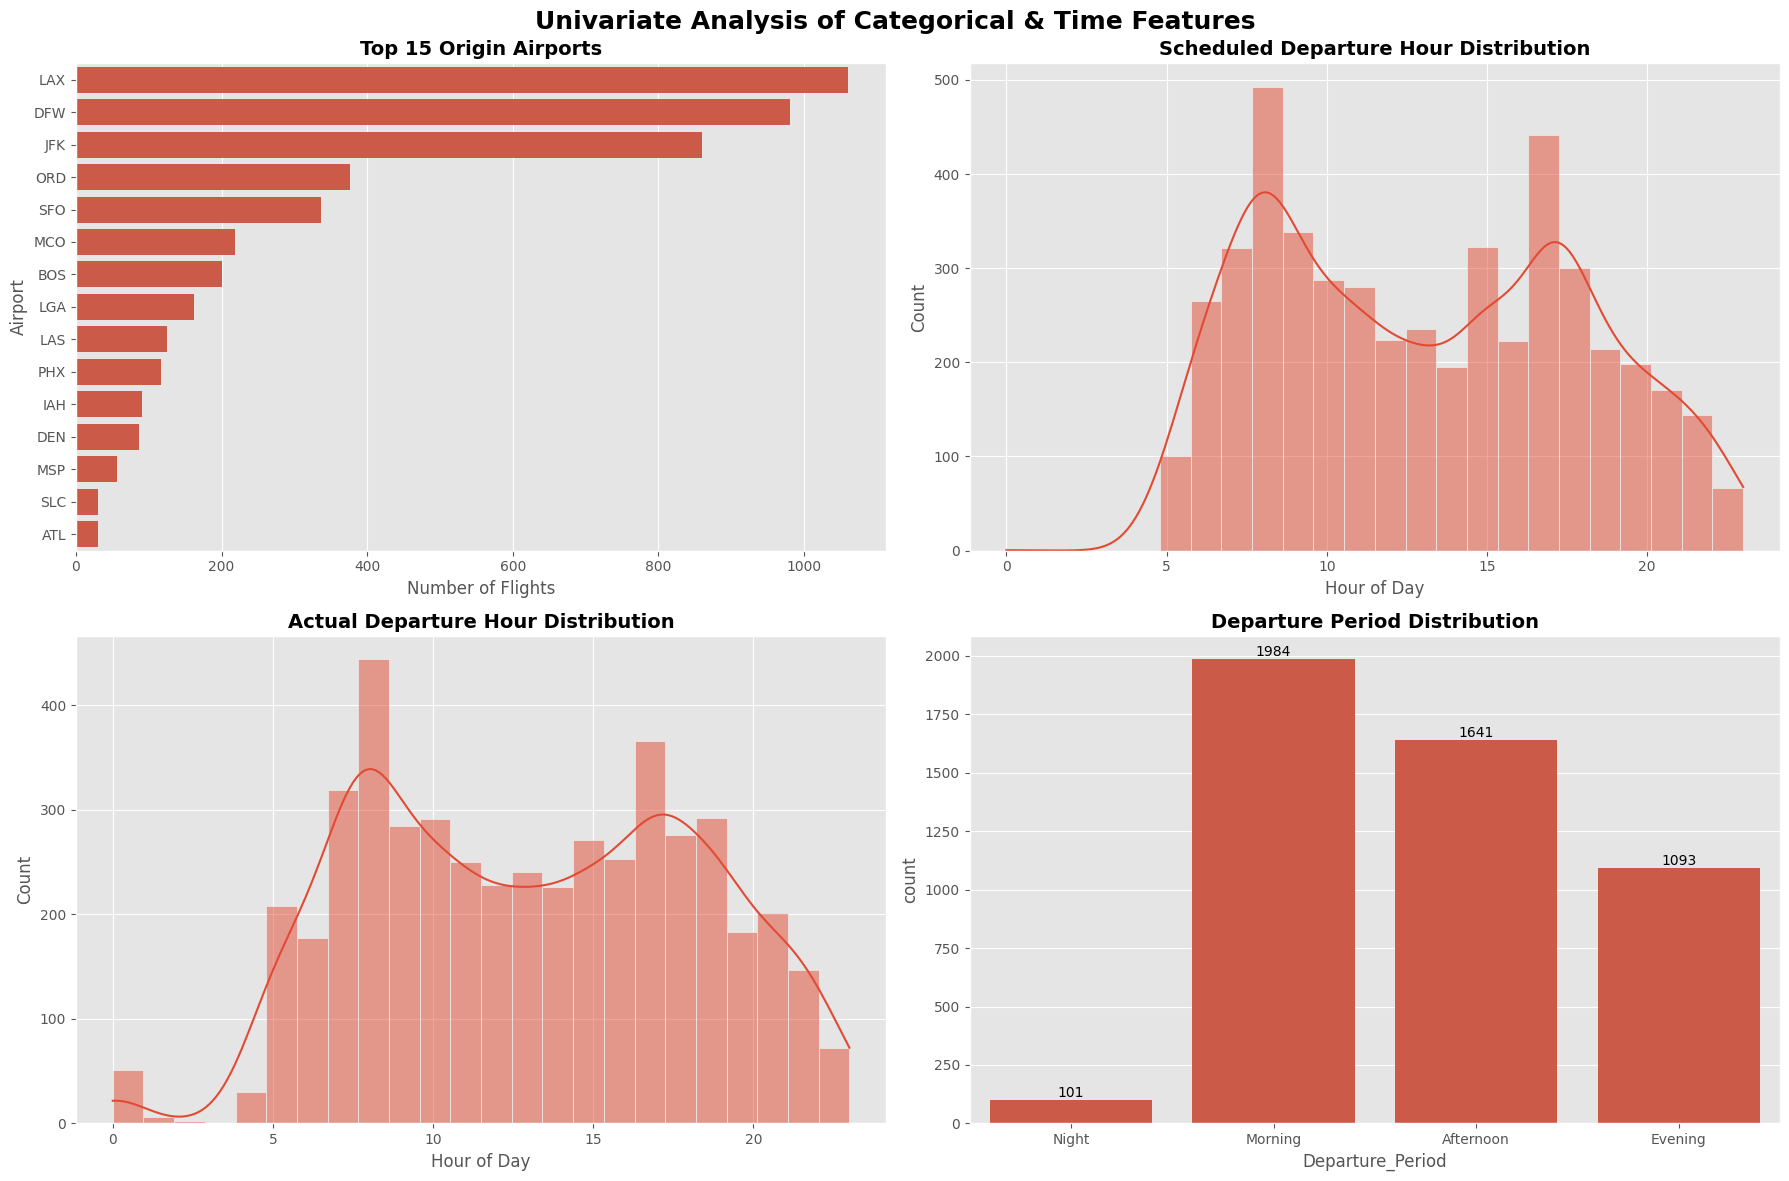

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove SettingWithCopyWarning
df = df.copy()

plt.style.use('ggplot')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top Origin Airports
top_airports = df['Origin_Airport'].value_counts().head(15)

sns.barplot(
    x=top_airports.values,
    y=top_airports.index,
    ax=axes[0, 0]
)

axes[0, 0].set_title('Top 15 Origin Airports', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Flights')
axes[0, 0].set_ylabel('Airport')

# 2. Scheduled Departure Distribution
sns.histplot(
    df['Scheduled_Departure'].apply(lambda x: x.hour),
    bins=24,
    kde=True,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    'Scheduled Departure Hour Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[0, 1].set_xlabel('Hour of Day')

# 3. Actual Departure Distribution
sns.histplot(
    df['Departure_Time'].apply(lambda x: x.hour),
    bins=24,
    kde=True,
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    'Actual Departure Hour Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[1, 0].set_xlabel('Hour of Day')

# 4. Departure Period Distribution
order = ['Night', 'Morning', 'Afternoon', 'Evening']

sns.countplot(
    data=df,
    x='Departure_Period',
    order=order,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    'Departure Period Distribution',
    fontsize=14,
    fontweight='bold'
)

for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container)

plt.suptitle(
    'Univariate Analysis of Categorical & Time Features',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#### Flight Scheduling & Departure Insights
- LAX had the highest number of departing flights, followed by DFW and JFK, making them the top three busiest origin airports in the dataset.
- Most flights are scheduled between 7 AM and 10 AM.
Another peak is observed between 3 PM and 6 PM.
- Very few flights are scheduled from midnight to 5 AM.
- The highest number of scheduled departures occurs around 8 AM.
- Most flights actually depart during the morning (6–9 AM) and late afternoon (4–7 PM), while very few departures occur during overnight hours (12–4 AM). This indicates that flight operations are concentrated during daytime hours.
- Overall, most flights depart in the morning, followed by afternoon and evening, while night departures are relatively rare.

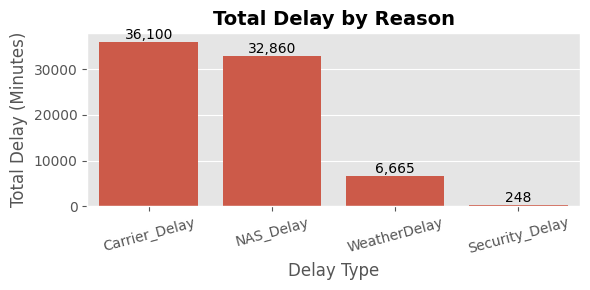

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total delay by reason
delay_reasons = (
    df[['Carrier_Delay',
        'WeatherDelay',
        'NAS_Delay',
        'Security_Delay']]
    .sum()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(6,3))

ax = sns.barplot(
    x=delay_reasons.index,
    y=delay_reasons.values
)

# Add value labels
for i, value in enumerate(delay_reasons.values):
    ax.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title(
    'Total Delay by Reason',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Delay Type')
plt.ylabel('Total Delay (Minutes)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

- Most of the delays are caused by carrier delay.

<Figure size 1400x800 with 0 Axes>

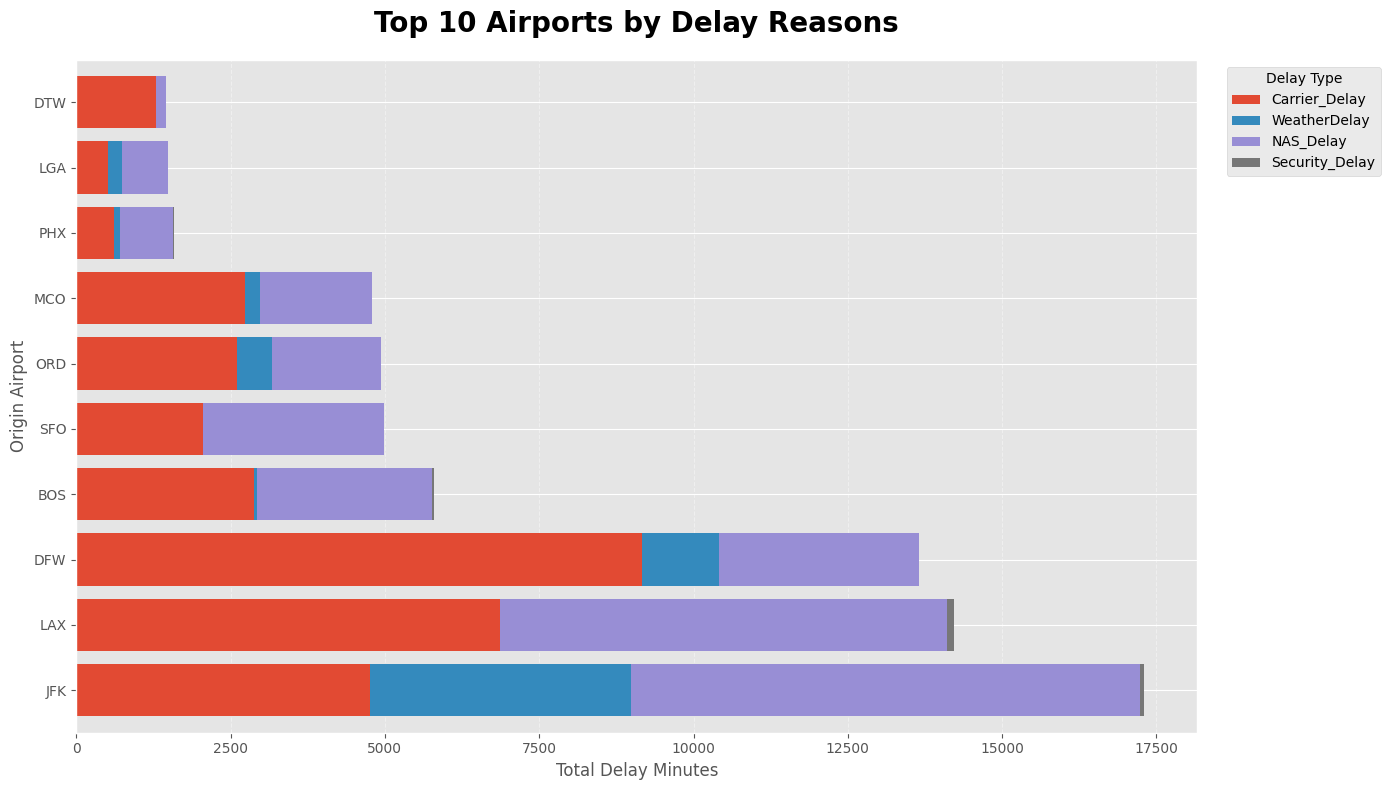

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Airport-wise delay summary
delay_by_airport = (
    df.groupby('Origin_Airport')[
        ['Carrier_Delay', 'WeatherDelay', 'NAS_Delay', 'Security_Delay']
    ]
    .sum()
)

# Total delay nikalna
delay_by_airport['Total_Delay'] = delay_by_airport.sum(axis=1)

# Top 10 airports
top10 = (
    delay_by_airport
    .sort_values('Total_Delay', ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(14, 8))

top10[
    ['Carrier_Delay', 'WeatherDelay', 'NAS_Delay', 'Security_Delay']
].plot(
    kind='barh',
    stacked=True,
    figsize=(14, 8),
    width=0.8
)

plt.title(
    'Top 10 Airports by Delay Reasons',
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xlabel('Total Delay Minutes', fontsize=12)
plt.ylabel('Origin Airport', fontsize=12)

plt.legend(
    title='Delay Type',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#### Insights from Graph
- The graph shows that the highest delays in flights are caused by Carrier_Delay and NAS_Delay.
- Airports like JFK, LAX, and DFW have the highest total delay.
The impact of Weather Delay is relatively low.
- Security Delay has the smallest contribution to total delays.

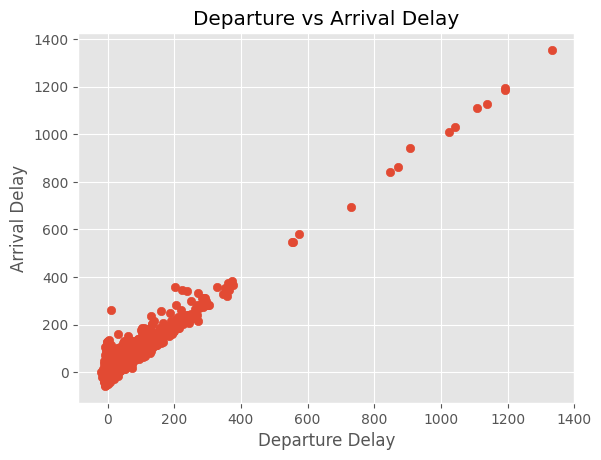

In [28]:
import matplotlib.pyplot as plt

plt.scatter(df['Dep_Delay'], df['Arrival_Delay'])
plt.xlabel("Departure Delay")
plt.ylabel("Arrival Delay")
plt.title("Departure vs Arrival Delay")
plt.show()

here is a strong positive correlation between departure delay and arrival delay.

In [29]:
df.columns

Index(['DayOfWeek', 'Origin_Airport', 'Scheduled_Departure', 'Departure_Time',
       'Dep_Delay', 'Scheduled_Arrival', 'Arrival_Time', 'Arrival_Delay',
       'Arr_Del_morethan15', 'Cancelled', 'Diverted', 'Distance',
       'Carrier_Delay', 'WeatherDelay', 'NAS_Delay', 'Security_Delay',
       'Late_Aircraft_Delay', 'Top_Carriers', 'Departure_Period'],
      dtype='object')

In [30]:
df['Cancelled'].isnull().sum()

np.int64(0)

In [31]:
df['Cancelled'] = df['Cancelled'].fillna(0)

In [32]:
df['Cancelled'] = df['Cancelled'].astype('float').fillna(0).astype(int)

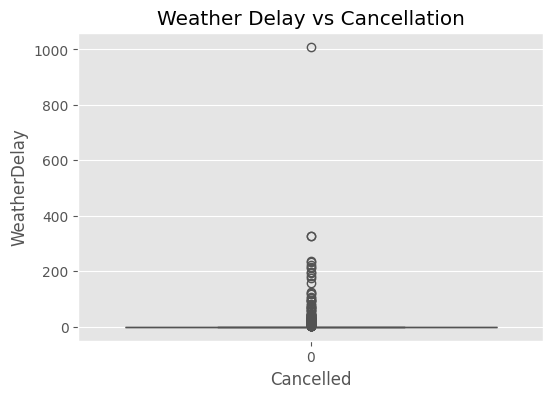

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
sns.boxplot(x='Cancelled', y='WeatherDelay', data=df)
plt.title("Weather Delay vs Cancellation")
plt.show()

In [34]:
df['WeatherDelay'].describe()

count    4819.000000
mean        1.383067
std        19.503961
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      1010.000000
Name: WeatherDelay, dtype: float64

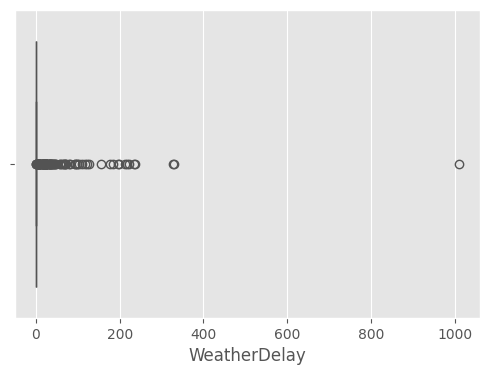

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.boxplot(x=df['WeatherDelay'])
plt.show()

In [36]:
df = df[df['WeatherDelay'] < df['WeatherDelay'].quantile(0.99)]

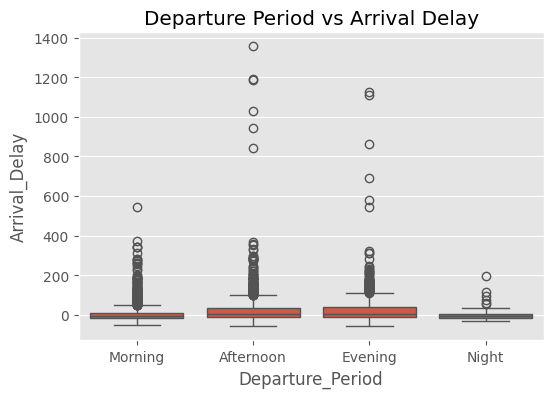

In [37]:

plt.figure(figsize=(6,4))
sns.boxplot(x='Departure_Period', y='Arrival_Delay', data=df)
plt.title("Departure Period vs Arrival Delay")
plt.show()

In [38]:
df[df['Departure_Period']=='Afternoon']['Arrival_Delay'].describe()

count    1617.000000
mean       25.217687
std        85.148238
min       -58.000000
25%       -10.000000
50%         4.000000
75%        34.000000
max      1355.000000
Name: Arrival_Delay, dtype: float64

In [39]:
def remove_outliers(group):
    q1 = group['Arrival_Delay'].quantile(0.25)
    q3 = group['Arrival_Delay'].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return group[(group['Arrival_Delay'] >= lower) & (group['Arrival_Delay'] <= upper)]

df = df.groupby('Departure_Period').apply(remove_outliers).reset_index(drop=True)

C:\Users\nehak\AppData\Local\Temp\ipykernel_12192\978367786.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Departure_Period').apply(remove_outliers).reset_index(drop=True)


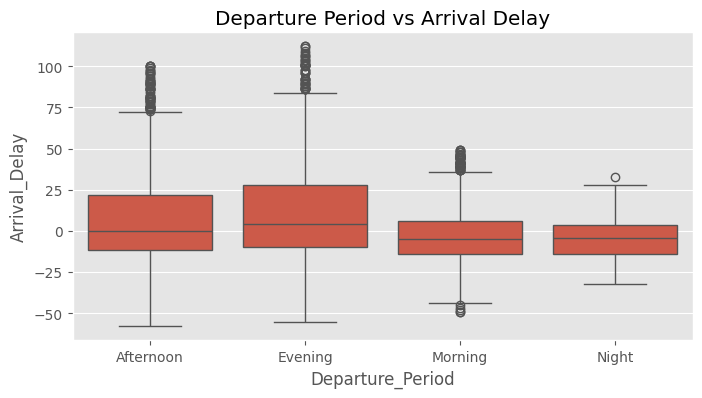

In [40]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Departure_Period', y='Arrival_Delay', data=df)
plt.title("Departure Period vs Arrival Delay")
plt.show()

Airlines can reduce delays by improving carrier operations, managing peak-hour congestion (morning & afternoon), optimizing air traffic coordination, and ensuring clean delay tracking data.

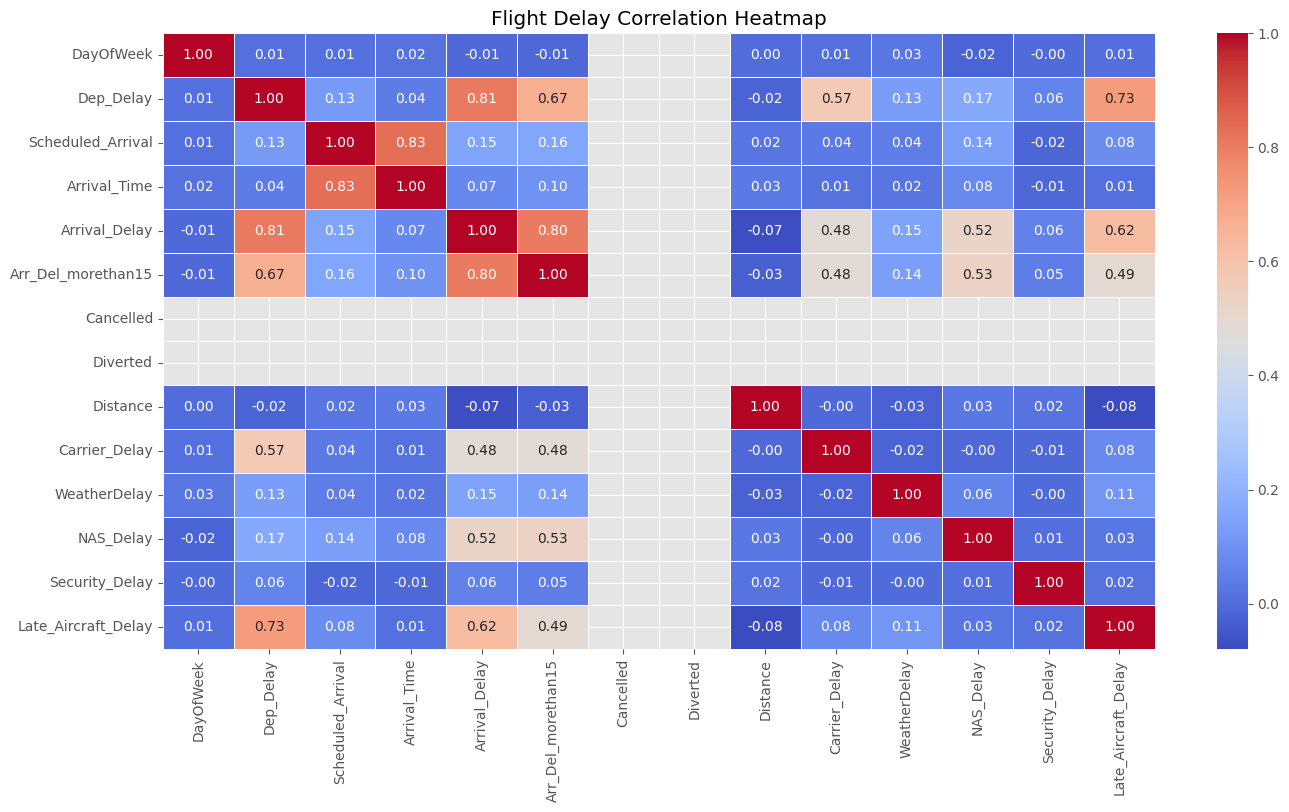

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'DayOfWeek', 'Dep_Delay', 'Scheduled_Arrival', 'Arrival_Time',
    'Arrival_Delay', 'Arr_Del_morethan15', 'Cancelled', 'Diverted',
    'Distance', 'Carrier_Delay', 'WeatherDelay', 'NAS_Delay',
    'Security_Delay', 'Late_Aircraft_Delay'
]

plt.figure(figsize=(16,8))
corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Flight Delay Correlation Heatmap")
plt.show()

- Flight jitni late udegi, utni hi late pahunchne ke chances hain.
- Jiska scheduled arrival time late hai, uska actual arrival time bhi generally late hota hai.
- Previous aircraft ke late aane ki wajah se departure delay badhta hai.
- Aircraft late mila to arrival bhi late hua.
- Week ka din delay ko zyada affect nahi kar raha.
-  Congestion badhega to arrival delay bhi badhega.

In [42]:
df.columns

Index(['DayOfWeek', 'Origin_Airport', 'Scheduled_Departure', 'Departure_Time',
       'Dep_Delay', 'Scheduled_Arrival', 'Arrival_Time', 'Arrival_Delay',
       'Arr_Del_morethan15', 'Cancelled', 'Diverted', 'Distance',
       'Carrier_Delay', 'WeatherDelay', 'NAS_Delay', 'Security_Delay',
       'Late_Aircraft_Delay', 'Top_Carriers', 'Departure_Period'],
      dtype='object')

#### 5 Hidden Patterns

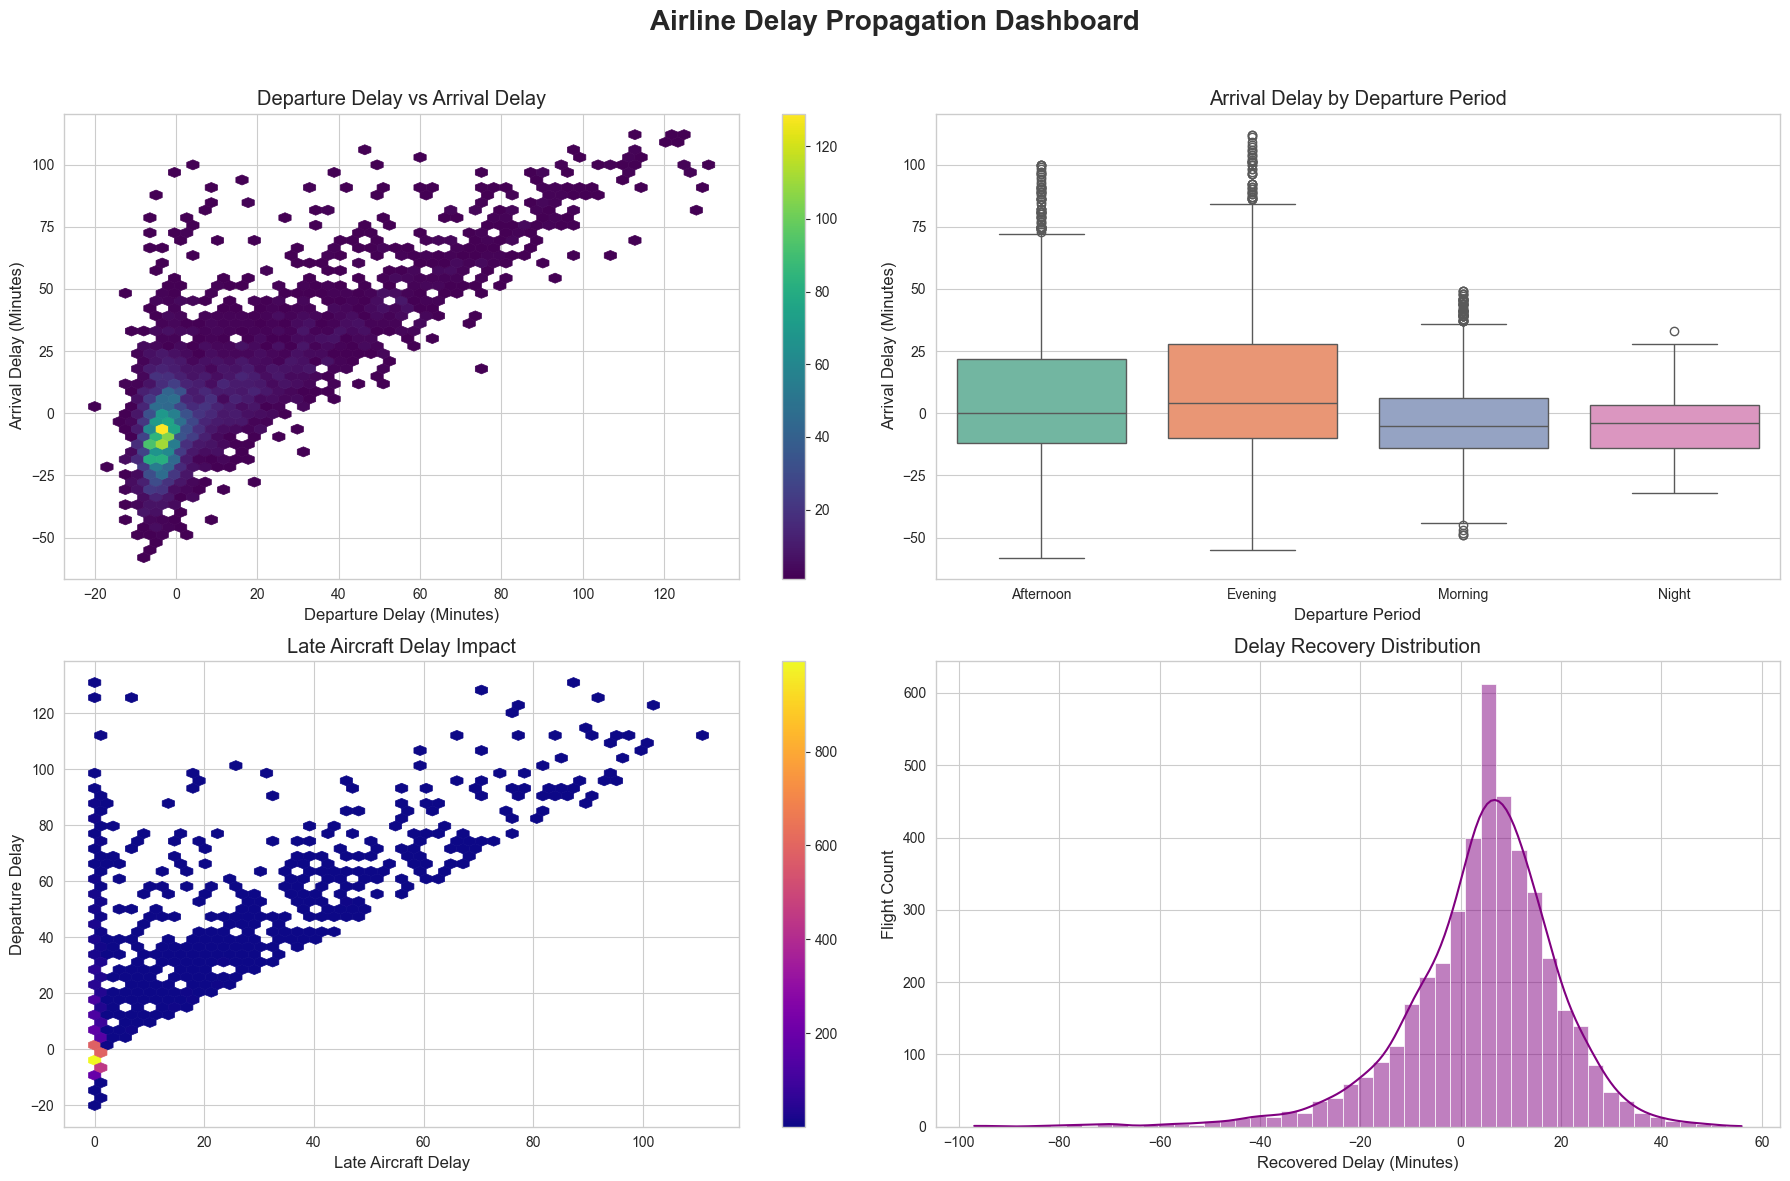

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    'Airline Delay Propagation Dashboard',
    fontsize=20,
    fontweight='bold'
)

# 1. Departure Delay vs Arrival Delay
hb = axes[0,0].hexbin(
    df['Dep_Delay'],
    df['Arrival_Delay'],
    gridsize=50,
    cmap='viridis',
    mincnt=1
)

fig.colorbar(hb, ax=axes[0,0])

axes[0,0].set_title('Departure Delay vs Arrival Delay')
axes[0,0].set_xlabel('Departure Delay (Minutes)')
axes[0,0].set_ylabel('Arrival Delay (Minutes)')


# 2. Arrival Delay by Departure Period
sns.boxplot(
    data=df,
    x='Departure_Period',
    y='Arrival_Delay',
    hue='Departure_Period',
    palette='Set2',
    legend=False,
    ax=axes[0,1]
)

axes[0,1].set_title('Arrival Delay by Departure Period')
axes[0,1].set_xlabel('Departure Period')
axes[0,1].set_ylabel('Arrival Delay (Minutes)')


# 3. Late Aircraft Impact
hb2 = axes[1,0].hexbin(
    df['Late_Aircraft_Delay'],
    df['Dep_Delay'],
    gridsize=50,
    cmap='plasma',
    mincnt=1
)

fig.colorbar(hb2, ax=axes[1,0])

axes[1,0].set_title('Late Aircraft Delay Impact')
axes[1,0].set_xlabel('Late Aircraft Delay')
axes[1,0].set_ylabel('Departure Delay')


# 4. Delay Recovery Distribution
df['Delay_Recovery'] = (
    df['Dep_Delay'] -
    df['Arrival_Delay']
)

sns.histplot(
    data=df,
    x='Delay_Recovery',
    bins=50,
    kde=True,
    color='purple',
    ax=axes[1,1]
)

axes[1,1].set_title('Delay Recovery Distribution')
axes[1,1].set_xlabel('Recovered Delay (Minutes)')
axes[1,1].set_ylabel('Flight Count')


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

- If a flight departs 30 minutes late, it usually also arrives late at the destination. Departure delay directly affects arrival delay.
- Evening flights have the highest median arrival delay, while morning flights have the lowest delay. Evening and afternoon flights show more variability and more outliers.
- If an aircraft arrives late from its previous flight, the next flight is also likely to depart late. A delay in one aircraft can impact multiple flights.
- Airlines can recover small delays during flight time, but it is difficult to recover large delays completely.

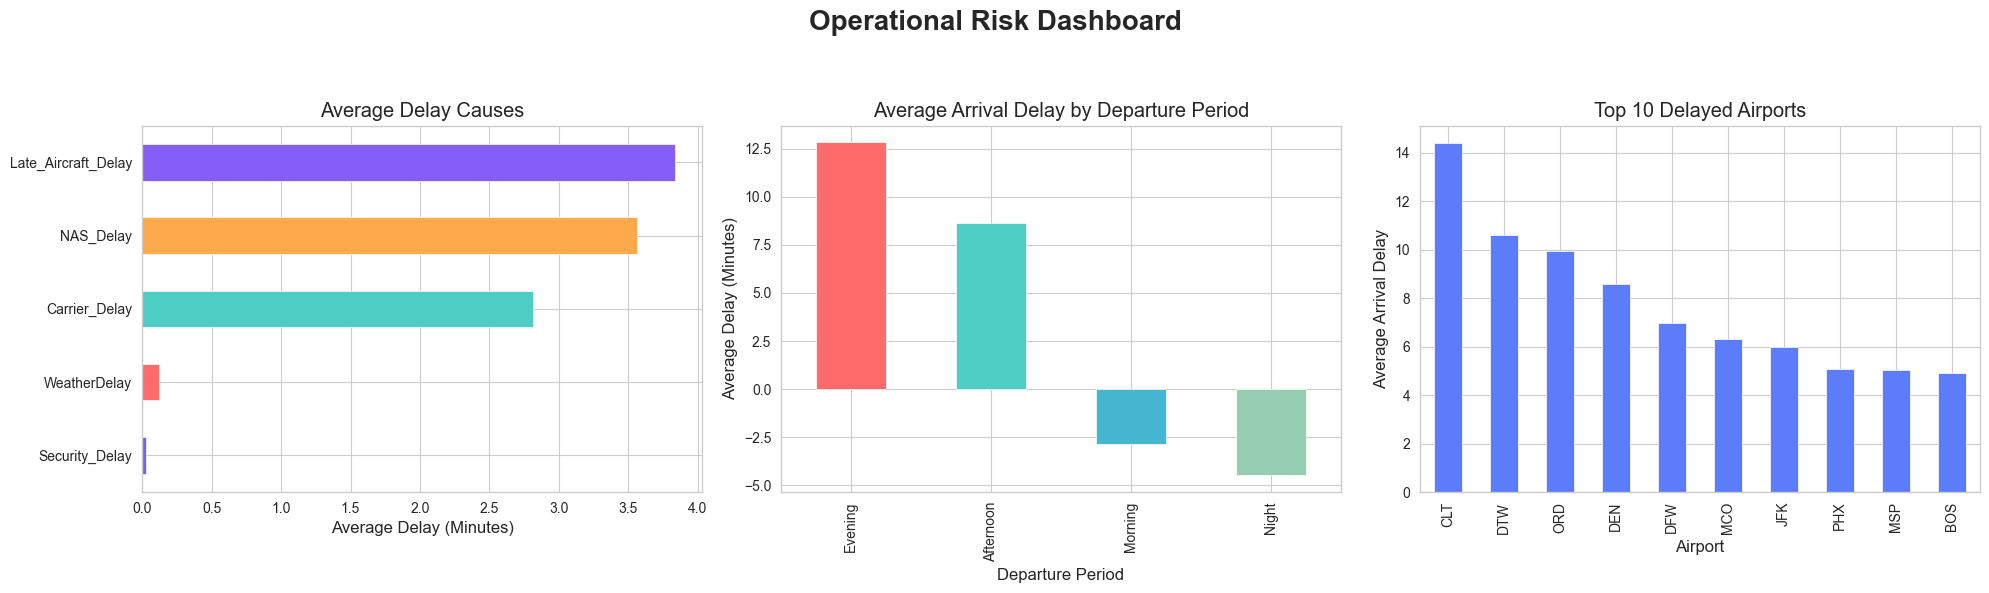

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fig.suptitle(
    'Operational Risk Dashboard',
    fontsize=20,
    fontweight='bold'
)

# 1. Average Delay Causes
delay_cols = [
    'Carrier_Delay',
    'WeatherDelay',
    'NAS_Delay',
    'Security_Delay',
    'Late_Aircraft_Delay'
]

delay_avg = (
    df[delay_cols]
    .mean()
    .sort_values()
)

delay_avg.plot(
    kind='barh',
    color=['#6C63FF','#FF6B6B','#4ECDC4','#FFA94D','#845EF7'],
    ax=axes[0]
)

axes[0].set_title('Average Delay Causes')
axes[0].set_xlabel('Average Delay (Minutes)')


# 2. Average Arrival Delay by Departure Period
period_delay = (
    df.groupby('Departure_Period')['Arrival_Delay']
      .mean()
      .sort_values(ascending=False)
)

period_delay.plot(
    kind='bar',
    color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'],
    ax=axes[1]
)

axes[1].set_title('Average Arrival Delay by Departure Period')
axes[1].set_xlabel('Departure Period')
axes[1].set_ylabel('Average Delay (Minutes)')


# 3. Top 10 Airports with Highest Arrival Delay
top_airports = (
    df.groupby('Origin_Airport')['Arrival_Delay']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top_airports.plot(
    kind='bar',
    color='#5C7CFA',
    ax=axes[2]
)

axes[2].set_title('Top 10 Delayed Airports')
axes[2].set_xlabel('Airport')
axes[2].set_ylabel('Average Arrival Delay')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

- Late Aircraft Delay is the biggest cause of flight delays.
- The most delayed flights tend to arrive late at their destinations.
- Morning flights generally arrive close to or earlier than the average time.
- Night flights have the least delay.
- CLT airport has the highest total delays among all airports.

In [45]:
df['Cancelled'].unique()

array([0])

In [46]:
df.groupby('Departure_Period')['Cancelled'].mean()

Departure_Period
Afternoon    0.0
Evening      0.0
Morning      0.0
Night        0.0
Name: Cancelled, dtype: float64